# word2vec 속도 개선

앞 장에서 word2vec의 구조를 배우고 CBOW 모델을 구현함   
CBOW 모델은 단순한 2층 신경망이라서 간단하게 구현할 수 있었음   
그러나 그 구현에는 몇 가지 문제가 있음   
가장 큰 문제는 말뭉치에 포함된 어휘 수가 많아지면 계산량도 커진다는 점   
실제로 어휘 수가 어느 정도를 넘어서면 앞 장의 CBOW 모델은 계산 시간이 오래 걸림   

그래서 이번 장의 목표는 word2vec의 속도 개선   
구체적으로는 앞 장의 단순한 word2vec에 두 가지 개선을 추가할 것   
- 첫 번째 개선은 Embedding이라는 새로운 계층을 도입함   
- 두 번째 개선은 네거티브 샘플링이라는 새로운 손실 함수를 도입   

이 두 가지 개선으로 '진짜' word2vec을 완성할 수 있음   
완성되면 PTB 데이터셋(실용적인 크기의 말뭉치)을 가지고 학습을 수행할 것   
그리고 그 결과로 얻은 단어의 분산 표현의 장점을 실제로 평가해볼 것

## word2vec 개선 1

우선 앞 장의 복습부터 시작   
앞 장에서는 아래 그림과 같은 CBOW 모델을 구현했음   
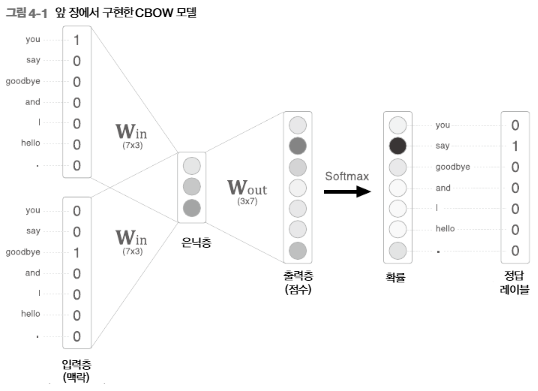   
- 그림과 같이 앞 장의 CBOW 모델은 단어 2개를 맥락으로 사용해, 이를 바탕으로 하나의 단어(타깃)를 추측함
- 이때 입력 측 가중치(Win)와의 행렬 곱으로 은닉층이 계산되고, 다시 출력 측 가중치(Wout)와의 행렬 곱으로 각 단어의 점수를 구함
- 그리고 이 점수에 소프트맥스 함수를 적용해 각 단어의 출현 확률을 얻고, 이 확률을 정답 레이블과 비교하여(정확히는 교차 엔트로피 오차를 적용하여) 손실을 구함   

> 앞 장에서는 맥락의 윈도우 크기를 1로 한정했음   
> 다시 말해 타깃 앞뒤 한 단어씩만 사용한 것   
> 이번 장에서는 나중에 어떤 크기의 맥락도 다룰 수 있도록 기능을 추가할 것   

위 그림의 CBOW 모델도 작은 말뭉치를 다룰 때는 특별히 문제될 게 없음   
그림에서 다루는 어휘 수는 모두 7개인데, 이 정도는 전혀 문제없이 처리할 수 있음   
그러나 거대한 말뭉치를 다루게 되면 몇 가지 문제가 발생함   

그 문제점을 보고자 어휘가 100만개, 은닉층의 뉴런이 100개인 CBOW 모델을 생각해보면   
word2vec은 아래 그림처럼 됨   
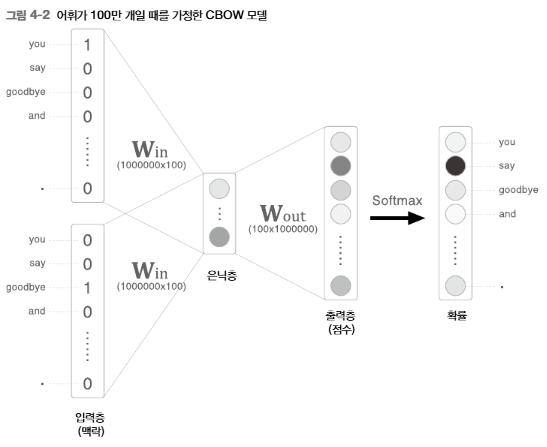   
- 그림에서 보듯, 입력층과 출력층에는 각 100만개의 뉴런이 존재함
- 이 수많은 뉴런 때문에 중간 계산에 많은 시간이 소요됨
- 정확히는 다음 두 계산이 병목이 됨
    - 입력층의 원핫 표현과 가중치 행렬 Win의 곱 계산
    - 은닉층과 가중치 행렬 Wout의 곱 및 Softmax 계층의 계산

첫 번째는 입력층의 원핫 표현과 관련한 문제   
단어를 원핫 표현으로 다루기 때문에 어휘 수가 많아지면 원핫 표현의 벡터 크기도 커지는 것   
예컨대 어휘가 100만개라면 그 원핫 표현 하나만 해도 원소 수가 100만 개인 벡터가 됨 - 상당한 메모리 차지   
게다가 이 원핫 벡터와 가중치 행렬 Win을 곱해야 하는데, 이것만으로 계산 자원을 상당히 사용하게 됨   
이 문제는 이번 절에서 Embedding 계층을 도입하는 것으로 해결함   

두 번째는 은닉층 이후의 계산   
우선 은닉층과 가중치 행렬 Wout의 곱만 해도 계산량이 상당함   
그리고 Softmax 계층에서도 다루는 어휘가 많아짐에 따라 계산량이 증가하는 문제가 있음   
이 문제는 다음 절에서 네거티브 샘플링이라는 새로운 손실 함수를 도입해 해결함   

### Embedding 계층

앞 장의 word2vec 구현에서는 단어를 원핫 표현으로 바꿨음   
그리고 그것을 MatMul 계층에 입력하고, MatMul 계층에서 가중치 행렬을 곱했음   
그럼 여기서 어휘 수가 100만개인 경우를 생각해보면   
이때 은닉층 뉴런이 100개라면, MatMul 계층의 행렬 곱은 아래 그림처럼 됨   
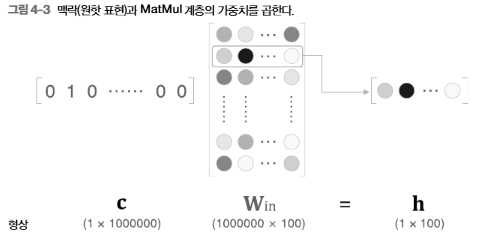   
- 그림처럼 만약 100만개의 어휘를 담은 말뭉치가 있다면, 단어의 원핫 표현도 100만 차원이 됨
- 그리고 이런 거대한 벡터와 가중치 행렬을 곱해야 하는 것
- 그러나 그림에서 결과적으로 수행하는 일은 단지 행렬의 특정 행을 추출하는 것뿐
- 따라서 원핫 표현으로의 변환과 MatMul 계층의 행렬곱 계산은 사실 필요가 없는 것   

그러면 가중치 매개변수로부터 '단어 ID에 해당하는 행(벡터)'을 추출하는 계층을 만들어보기 - Embedding 계층   
Embedding이란 단어 임베딩(word embedding)이라는 용어에서 유래함   
즉, Embedding 계층에 단어 임베딩(분산 표현)을 저장하는 것   

> 자연어 처리 분야에서 단어의 밀집벡터 표현을 **단어 임베딩** 혹은 단어의 **분산 표현(distributed representation)** 이라 함   
> 참고로, 통계 기반 기법으로 얻은 단어 벡터는 영어로 distributional representation이라고 하고,   
> 신경망을 사용한 추론 기반 기법으로 얻은 단어 벡터는 distributed representation이라고 함   
> 단어는 미묘하게 다르지만, 이 책에서는 둘 다 '분산 표현'으로 번역함

### Embedding 계층 구현

행렬에서 특정 행을 추출하기란 아주 쉬움   
예컨대 가중치 W가 2차원 넘파이 배열일 때, 이 가중치로부터 특정 행을 추출하려면 그저 W[2]나 W[5]처럼 원하는 행을 명시하면 됨   

In [1]:
import numpy as np
W = np.arange(21).reshape(7, 3)
print(W)
print(W[2])
print(W[5])

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]]
[6 7 8]
[15 16 17]


또한 가중치 W로부터 여러 행을 한꺼번에 추출하는 일도 간단하게 할 수 있음   
원하는 행 번호들을 배열에 나열하기만 하면 됨

In [2]:
idx = np.array([1, 0, 3, 0])
print(W[idx])

[[ 3  4  5]
 [ 0  1  2]
 [ 9 10 11]
 [ 0  1  2]]


- 이 예에서는 인덱스 4개(1, 0, 3, 0번째)를 한 번에 추출했음
- 이처럼 인수에 배열을 사용하면 여러 행도 한꺼번에 추출할 수 있음
- 참고로, 이는 미니배치 처리를 가정했을 경우의 구현   

그럼 Embedding 계층의 forward() 메서드를 구현해보면

In [3]:
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
    
    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

- 이 책의 구현 규칙에 따라 인스턴스 변수 params와 grads를 사용함
- 또한 인스턴스 변수 idx에는 추출하는 행의 인덱스(단어 ID)를 배열로 저장함

이어서 역전파(backward)를 생각해보기   
Embedding 계층의 순전파는 가중치 W의 특정 행을 추출할 뿐이었음   
단순히 가중치의 특정 행 뉴런만을 (아무것도 손대지 않고) 다음 층으로 흘려보낸 것   
따라서 역전파에서는 앞 층(출력 측 층)으로부터 전해진 기울기를 다음 층(입력 측 층)으로 그대로 흘려주면 됨   
다만, 앞 층으로부터 전해진 기울기를 가중치 기울기 dW의 특정 행(idx번째 행)에 설정함   
그림으로는 다음과 같음   
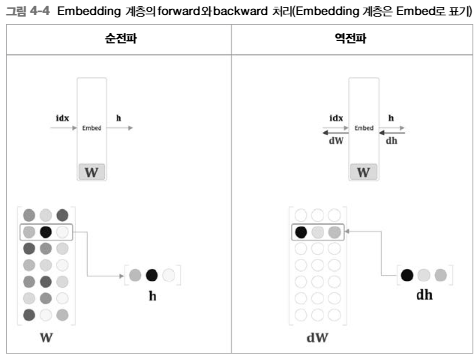   
여기까지를 기초로 backward()를 구현해보면

In [4]:
def backward(self, dout):
    dW, = self.grads
    dW[...] = 0
    dW[self.idx] = dout  # 사실은 나쁜 예
    return None

- 이 코드는 가중치 기울기 dW를 꺼낸 다음
- dW[...] = 0에서 dW의 원소를 0으로 덮어씀(dW 자체를 0으로 설정하는 게 아니라, dW의 형상을 유지한 채, 그 원소들을 0으로 덮어쓰는 것)
- 그리고 앞 층에서 전해진 기울기 dout을 idx번째 행에 할당함   

> 여기에서는 가중치 W와 크기가 같은 행렬 dW를 만들고, dW의 특정 행에 기울기를 할당했음   
> 그러나 최종적으로 하고 싶은 일은 가중치 W를 갱신하는 것이므로 일부러 dW와 같은 (W와 같은 크기의) 행렬을 만들 필요는 없음   
> 이렇게 하지 않고, 갱신하려는 행 번호(idx)와 그 기울기(dout)를 따로 저장해두면, 이 정보로부터 가중치(W)의 특정 행만 갱신할 수 있음   
> 다만 여기에서는 갱신용 클래스(Optimizer)와 조합해 사용하는 것을 고려해 지금처럼 구현했음   

그런데 앞의 backward() 구현에는 사실 문제가 하나 있음   
그 문제는 idx의 원소가 중복될 때 발생   
예컨대 idx가 [0, 2, 0, 4]일 경우를 생각해보면 아래 그림과 같은 문제가 생김   
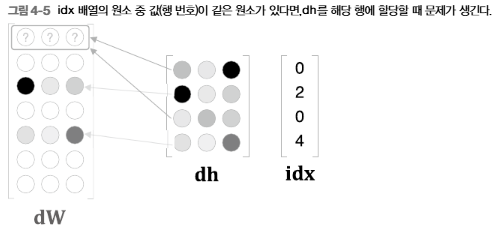   
- 그림과 같이 dh의 각 행 값을 idx가 가리키는 장소에 할당해보면   
- dW의 0번째 행에 2개의 값이 할당됨
- 먼저 쓰여진 값을 덮어쓴다는 뜻   

이 중복 문제를 해결하려면 '할당'이 아닌 '더하기'를 해야함   
즉, dh의 각 행의 값을 dW의 해당 행에 더해줌   
이렇게 제대로 구현해보면

In [5]:
def backward(self, dout):
    dW, = self.grads
    dW[...] = 0

    for i, word_id in enumerate(self.idx):
        dW[word_id] += dout[i]
    
    # 혹은
    # np.add.at(dW, self.idx, dout)

        return None

- 여기에서는 for문을 사용해 해당 인덱스에 기울기를 더했음
- 이것으로 idx에 중복 인덱스가 있더라도 올바르게 처리됨
- for문 대신 넘파이의 np.add.at()을 사용해도 됨
- np.add.at(A, idx, B)는 B를 A의 idx번째 행에 더해줌   

> 일반적으로 파이썬에서 for문보다는 넘파이의 내장 메서드를 사용하는 편이 더 빠름   
> 넘파이의 메서드에는 속도와 효율을 높여주는 최적화가 적용돼 있기 때문   
> 따라서 앞의 소스 코드도 for문 대신 np.add.at()을 사용하도록 수정하면 효율이 훨씬 좋아짐   

여기까지 Embedding 계층을 구현해봤음   
이제 word2vec(CBOW 모델)의 구현은 입력 측 MatMul 계층을 Embedding 계층으로 전환할 수 있음   
그 효과로 메모리 사용량을 줄이고 쓸데없는 계산도 생략할 수 있게 됨

In [6]:
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
        np.add.at(dW, self.idx, dout)
        return None

## word2vec 개선 2

앞에서 이야기했듯이, 남은 병목은 은닉층 이후의 처리(행렬 곱과 Softmax 계층의 계산)   
이 병목을 해소하는 게 이번 절의 목표 - **네거티브 샘플링(부정적 샘플링)** 이라는 기법을 사용해서   
Softmax 대신 네거티브 샘플링을 이용하면 어휘가 아무리 많아져도 계산량을 낮은 수준에서 일정하게 억제할 수 있음   

### 은닉층 이후 계산의 문제점

은닉층 이후 계산의 문제점을 알아보기 위해, 앞 절과 마찬가지로 어휘가 100만개, 은닉층 뉴런이 100개일 때의 word2vec(CBOW 모델)을 예로 생각해보면   
이때 word2vec이 수행하는 작업은 다음과 같음   
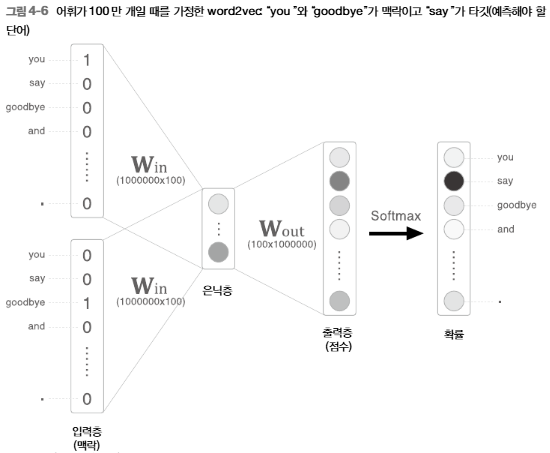   
- 그림에서 보듯, 입력층과 출력층에는 뉴런이 각 100만개씩 존재함
- 앞 절에서는 Embedding 계층을 도입하여 입력층 계산에서의 낭비를 줄였음
- 남은 문제는 은닉층 이후의 처리, 은닉층 이후에서 계산이 오래 걸리는 곳은 다음 두 부분
    - 은닉층의 뉴런과 가중치 행렬(Wout)의 곱
    - Softmax 계층의 계산

첫 번째는 거대한 행렬을 곱하는 문제   
앞의 예에서는 은닉층의 벡터 크기가 100이고, 가중치 행렬의 크기가 100 X 100만   
이렇게 큰 행렬의 곱을 계산하려면 시간이 오래 걸림(그리고 메모리도 많이 필요)   
또한 역전파 때도 같은 계산을 수행하기 때문에 이 행렬 곱을 '가볍게' 만들어야 함   

두 번째로, Softmax에서도 같은 문제가 발생함   
즉 어휘가 많아지면 Softmax의 계산량도 증가함   
이 사실은 Softmax의 식을 보면 더욱 명확해짐   
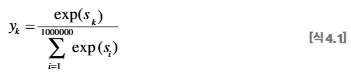   
- 식은 k번째 원소(단어)를 타깃으로 했을 때의 Softmax 계산식(점수의 각 원소는 s1, s2, ...)   
- 이 식에서는 어휘 수를 100만개로 가정했으므로 분모의 값을 얻으려면 exp 계산을 100만번 수행해야 함
- 이 계산도 어휘 수에 비례해 증가하므로 Softmax를 대신할 '가벼운' 계산이 필요

### 다중 분류에서 이진 분류로

지금부터 네거티브 샘플링 기법이 무엇인지 알아보기   
이 기법의 핵심 아이디어는 '이진 분류(binary classification)'에 있음   
더 정확하게 말하면, '다중 분류(multi-class classification)'(혹은 다중 클래스 분류)를 '이진 분류'로 근사하는 것이 네거티브 샘플링을 이해하는 데 중요한 포인트   

지금까지는 '다중 분류'문제를 다뤄왔음   
바로 앞 절에서도 100만개의 단어 중에서 옳은 단어 하나를 선택하는 문제였음   

> 이진 분류는 'Yes/No'로 답하는 문제를 다룸   
> 예컨대 '이 숫자는 7입니까?', '이 동물은 고양이입니까?', '타깃 단어는 say입니까?' 같은 문제는 모두 'Yes/No'로 답할 수 있음   

지금까지는 맥락이 주어졌을 때 정답이 되는 단어를 높은 확률로 추측하도록 만드는 일을 했음   
예컨대 맥락으로 'you'와 'goodbye'를 주면 정답인 'say'의 확률이 높아지도록 신경망을 학습시켰음   
그리고 학습이 잘 이뤄지면 그 신경망은 올바른 추측을 수행하게 됨   
즉, 이 신경망은 "맥락이 'you'와 'goodbye'일 때, 타깃 단어는 무엇입니까?"라는 질문에 올바른 답을 내어줄 수 있음   

이제부터 생각해야 할 것은 '다중 분류' 문제를 '이진 분류' 방식으로 해결하는 것   
그러기 위해서는 'Yes/No'로 답할 수 있는 질문을 생각해내야 함   
예컨대 "맥락이 'you'와 'goodbye'일 때, 타깃 단어는 'say'입니까?"라는 질문에 답하는 신경망을 생각해내야 함   
이렇게 하면 출력층에는 뉴런을 하나만 준비하면 됨   
출력층의 이 뉴런이 'say'의 점수를 출력하는 것   

그럼 이때 CBOW 모델에서 벌어지는 일은 다음과 같음   
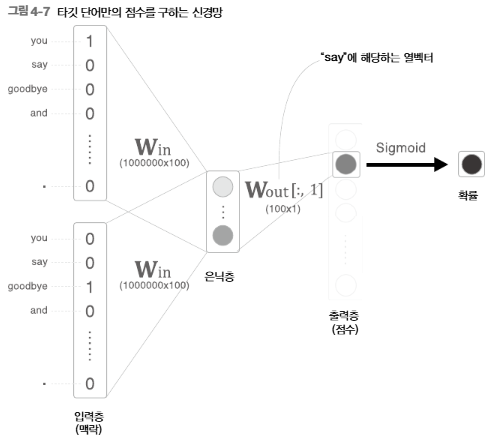   
- 그림에서 보듯 출력층의 뉴런은 하나뿐
- 따라서 은닉층과 출력 측의 가중치 행렬의 내적은 'say'에 해당하는 열(단어 벡터)만을 추출하고, 그 추출된 벡터와 은닉층 뉴런과의 내적을 계산하면 끝   

다음 그림은 이 계산을 자세히 그린 것   
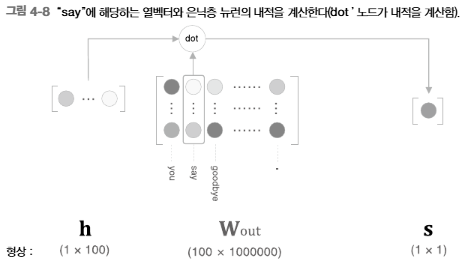   
- 그림처럼 출력 측의 가중치 Wout에서는 각 단어 ID의 단어 벡터가 각각의 열로 저장되어 있음
- 이 예에서는 'say'에 해당하는 단어 벡터를 추출함
- 그리고 그 벡터와 은닉층 뉴런과의 내적을 구함 - 이렇게 구한 값이 최종 점수   

> 이전까지의 출력층에서는 모든 단어를 대상으로 계산을 수행했음   
> 하지만 여기에서는 'say'라는 단어 하나에 주목하여 그 점수만을 계산하는 게 차이   
> 그리고 시그모이드 함수를 이용해 그 점수를 확률로 변환함

### 시그모이드 함수와 교차 엔트로피 오차

이진 분류 문제를 신경망으로 풀려면 점수에 시그모이드 함수를 적용해 확률로 변환하고, 손실을 구할 때는 손실 함수로 '교차 엔트로피 오차'를 사용함   
이 둘은 이진 분류 신경망에서 가장 흔하게 사용하는 조합   

> 다중 분류의 경우, 출력층에서는 (점수를 확률로 변환할 때) '소프트맥스 함수'를, 손실 함수로는 '교차 엔트로피 오차'를 이용함   
> 이진 분류의 경우, 출력층에서는 '시그모이드 함수'를, 손실 함수로는 '교차 엔트로피 오차'를 이용함   

먼저 시그모이드 함수를 복습해보면   
시그모이드 함수는 다음과 같이 씀   
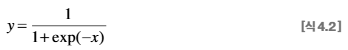   
- 식을 그래프로 그리면 아래 그림의 오른쪽처럼 나옴

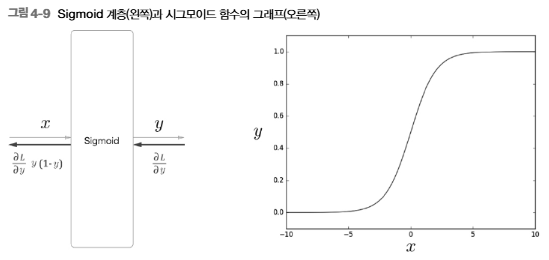   
- 그림에서 알 수 있듯이, 그래프는 S자 곡선 형태이며, 입력 값(x)은 0에서 1 사이의 실수로 변환됨
- 여기서의 핵심은 시그모이드 함수의 출력(y)을 '확률'로 해석할 수 있다는 것   
- 또한 시그모이드 함수는 Sigmoid 계층으로 이미 구현해 두었음, 계산 그래프로는 왼쪽 그림처럼 그릴 수 있음   

시그모이드 함수를 적용해 확률 y를 얻으면, 이 확률 y로부터 손실을 구함   
시그모이드 함수에 사용되는 손실 함수는 다중 분류 때처럼 '교차 엔트로피 오차'   
교차 엔트로피 오차는 다음과 같이 쓸 수 있음   
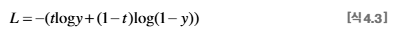   
- 여기에서 y는 시그모이드 함수의 출력이고, t는 정답 레이블
- 이 정답 레이블의 값은 0 혹은 1
- t가 1이면 정답이 'Yes'이고, 0이면 'No'
- 따라서 t가 1이면 -logy가 출력되고, 반대로 t가 0이면 -log(1-y)가 출력됨   

> 이진 분류와 다중 분류 모두 손실 함수로 '교차 엔트로피 오차'를 사용함   
> 각각의 수식은 서로 다르지만, 결국 의미는 같음   
> 정확히 말하면, 다중 분류에서 출력층에 뉴런을 2개만 사용할 경우 이진 분류의 식과 같아짐   
> 따라서 Softmax with Loss 계층의 코드를 조금만 손보면 Sigmoid with Loss 계층도 구현할 수 있음   

이어서 Sigmoid 계층과 Cross Entropy Error 계층의 계산 그래프를 살펴보면   
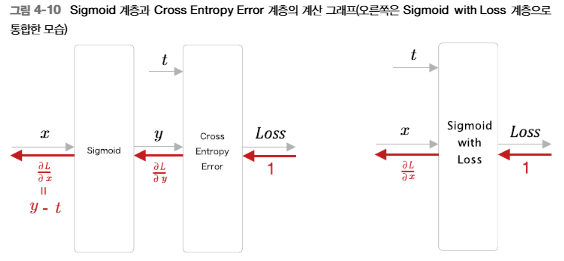   
- 그림에서 주목할 점은 역전파의 y-t 값
    - y-t로 유도되는 과정   
    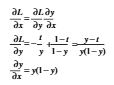
- 여기에서 y는 신경망이 출력한 확률이고, t는 정답 레이블
- 그리고 y-t는 정확히 그 두 값의 차이인 것
- 예컨대 정답 레이블이 1이라면, y가 1(100%)에 가까워질수록 오차가 줄어든다는 뜻
- 반대로 y가 1로부터 멀어지면 오차가 커짐
- 그리고 그 오차가 앞 계층으로 흘러가므로, 오차가 크면 '크게' 학습하고, 오착 작으면 '작게' 학습하게 됨   

> '시그모이드 함수'와 '교차 엔트로피 오차'를 조합하여 역전파의 값이 y-t라는 '깔끔한 결과'를 도출했음   
> 마찬가지로 '소프트맥스 함수'와 '교차 엔트로피 오차'의 조합, 또는 '항등 함수'와 '2 제곱 오차'의 조합에서도 역전파 시에는 y-t 값이 전파됨

### 다중 분류에서 이진 분류로 (구현)

지금까지의 내용을 구현 관점에서 정리   
지금까지 다중 분류 문제를 다뤘음   
다중 분류에서는 출력층에 어휘 수만큼의 뉴런을 준비하고 이 뉴런들이 출력한 값을 Softmax 계층에 통과시켰음   
이때 이용되는 신경망을 '계층'과 '연산' 중심으로 그리면 아래 그림처럼 됨   
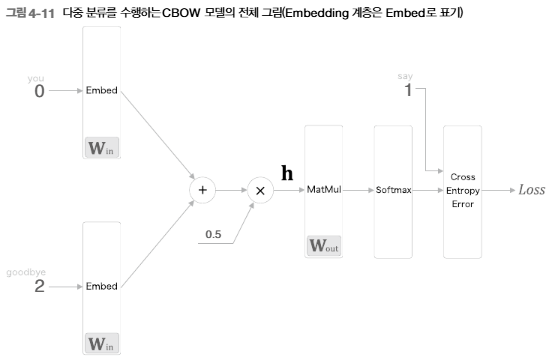   
- 그림은 맥락이 'you'와 'goodbye'이고, 정답이 되는 타깃(예측해야 할 단어)이 'say'인 경우의 예(단어 ID는 'you'가 0, 'say'가 1, 'goodbye'가 2라고 가정했음)
- 또한 입력층에서는 각각에 대응하는 단어 ID의 분산 표현을 추출하기 위해 Embedding 계층을 사용했음

> 앞 절에서는 Embedding 계층을 구현했음   
> 이 계층은 대상 단어 ID의 분산 표현(단어 벡터)을 추출함   
> 이전에는 Embedding 계층 자리에 MatMul 계층을 사용했음   

그럼 위 그림의 신경망을 이진 분류 신경망으로 변환해보면   
우선 신경망 구성부터 보면   
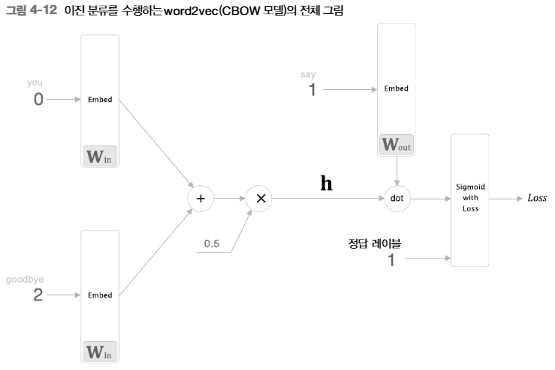   
- 여기에서는 은닉층 뉴런 h와, 출력 측의 가중치 Wout에서 단어 'say'에 해당하는 단어 벡터와의 내적을 계산함
- 그리고 그 출력을 Sigmoid with Loss 계층에 입력해 최종 손실을 얻음   

> 그림에서는 Sigmoid with Loss 계층에 정답 레이블로 '1'을 입력하고 있음   
> 이는 현재 문제의 답이 'Yes'임을 의미함   
> 답이 'No'라면 Sigmoid with Loss에 정답 레이블로 '0'을 입력해야 함   

더 쉽게 풀어가기 위해 위 그림의 후반부를 더 단순화   
이를 위해 Embedding Dot 계층을 도입함   
이 계층은 위 그림의 Embedding 계층과 'dot 연산(내적)'의 처리를 합친 계층   
이 계층을 사용하면 아래 그림처럼 그릴 수 있음   
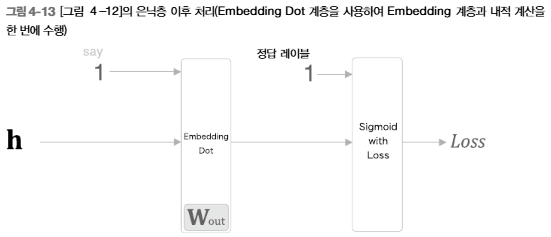   
- 은닉층 뉴런 h는 Embedding Dot 계층을 거쳐 Sigmoid with Loss 계층을 통과함
- 보다시피 Embedding Dot 계층을 사용하면서 은닉층 이후의 처리가 간단해졌음   

Embedding Dot 계층의 구현을 간단히 살펴보면

In [7]:
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh

- EmbeddingDot 클래스에는 총 4개의 인스턴스(embed, params, grads, cache)가 있음
- 이 책의 구현 규칙대로 params에는 매개변수를 저장하고, grads에는 기울기를 저장함
- 또, embed는 Embedding 계층을, cache는 순전파 시의 계산 결과를 잠시 유지하기 위한 변수로 사용함
- 순전파를 담당하는 forward(h, idx) 메서드는 인수로 은닉층 뉴런(h)과 단어 ID의 넘파이 배열(idx)을 받음
- 여기에서 idx는 단어 ID의 '배열'인데, 배열로 받는 이유는 데이터를 한꺼번에 처리하는 '미니배치 처리'를 가정했기 때문
- 이 코드의 forward() 메서드에서는 우선 Embedding 계층의 forward(idx)를 호출한 다음 내적을 계산함
- 내적 계산은 np.sum(self.target_W * h, axis=1)이라는 단 한 줄로 이뤄짐   

이 구현을 이해하려면 구체적인 값을 보는 편이 빠름   
아래 그림이 구체적인 예시   
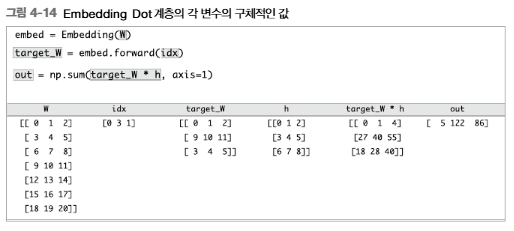   
- 그림과 같이, 적당한 W와 h, 그리고 idx를 준비함
- 여기에서 idx가 [0, 3, 1]인데, 이는 3개의 데이터를 미니배치로 한 번에 처리하는 예임을 뜻함
- idx가 [0, 3, 1]이므로 target_W는 W의 0번, 3번, 1번째 행을 추출한 결과
- 그리고 target_W * h는 각 원소의 곱을 계산함(넘파이 배열의 * 연산은 원소별 곱을 수행함)
- 그리고 이 결과를 행마다(axis=1) 전부 더해 최종 결과 out을 얻음   

여기까지가 Embedding Dot 계층의 순전파   
역전파는 순전파의 반대 순서로 기울기를 전달해 구현함   

### 네거티브 샘플링

지금까지 배운 것으로 주어진 문제를 '다중 분류'에서 '이진 분류'로 변환할 수 있음   
하지만 안타깝게도 이것만으로는 문제가 다 해결되지 않음   
지금까지는 긍정적인 예(정답)에 대해서만 학습했기 때문   
다시 말해 부정적인 예(오답)를 입력하면 어떤 결과가 나올지 확실하지 않음   

앞의 예를 다시 한번 생각해보면   
앞의 예란 맥락이 'you'와 'goodbye'이고, 정답 타깃이 'say'인 경우   
지금까지는 긍정적 예인 'say'만을 대상으로 이진 분류를 해왔음   
만약 여기서 '좋은 가중치'가 준비되어 있다면 Sigmoid 계층의 출력(확률)은 1에 가까울 것   
이때의 처리를 계산 그래프로는 아래 그림처럼 그릴 수 있음   
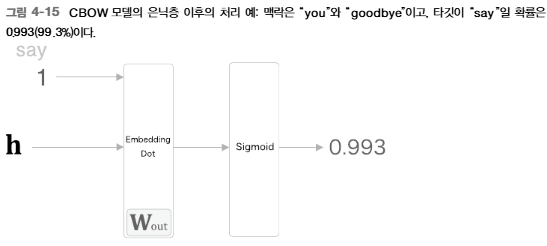   
- 현재의 신경망에서는 긍정적 예인 'say'에 대해서만 학습하게 됨
- 그러나 부정적 예('say' 이외의 단어)에 대해서는 어떠한 지식도 획득하지 못함
- 여기에서 해야하는 것은 바로 긍정적 예('say')에 대해서는 Sigmoid 계층의 출력을 1에 가깝게 만들고, 
- 부정적 예('say' 이외의 단어)에 대해서는 Sigmoid 계층의 출력을 0에 가깝게 만드는 것   

이것을 그림으로 나타내면   
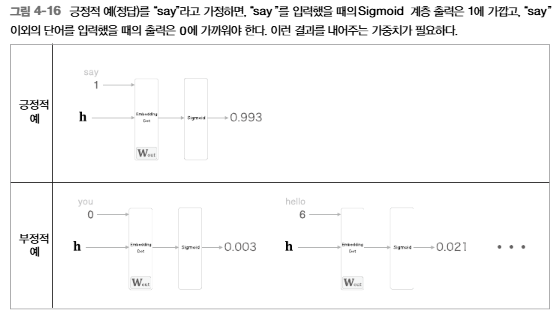   
- 예컨대 맥락이 'you'와 'goodbye'일 때, 타깃이 'hello'일 확률(틀린 단어일 경우의 확률)은 낮은 값이어야 바람직
- 그림에서 타깃이 'hello'일 확률은 0.021(2.1%)
- 그리고 이런 결과를 만들어주는 가중치가 필요   

> 다중 분류 문제를 이진 분류로 다루려면 '정답(긍정적 예)'과 '오답(부정적 예)' 각각에 대해 바르게 (이진) 분류할 수 있어야 함   
> 따라서 긍정적 예와 부정적 예 모두를 대상으로 문제를 생각해야 함   

그렇다고 모든 부정적 예를 대상으로 하여 이진 분류를 학습시키는 것은 물론 아님   
모든 부정적 예를 대상으로 하는 방법은 어휘 수가 늘어나면 감당할 수 없기 때문(어휘 수 증가에 대처하는 것이 이번 장의 목적)   
그래서 근사적인 해법으로, 부정적 예를 몇 개(5개라든지, 10개라든지) 선택함   
즉, 적은 수의 부정적 예를 샘플링해 사용함   
이것이 바로 '네거티브 샘플링'기법이 의미라는 바   

정리하면, 네거티브 샘플링 기법은 긍정적 예를 타깃으로 한 경우의 손실을 구함   
그와 동시에 부정적 예를 몇 개 샘플링(선별)하여, 그 부정적 예에 대해서도 마찬가지로 손실을 구함   
그리고 각각의 데이터(긍정적 예와 샘플링된 부정적 예)의 손실을 더한 값을 최종 손실로 함   

위 내용을 지금까지와 같은 예시를 들어 살펴보면   
긍정적 예의 타깃은 'say', 부정적 예의 타깃을 2개('hello'와 'I') 샘플링했다고 가정   
이제 CBOW 모델의 은닉층 이후만 주목하면 네거티브 샘플링의 계산 그래프는 아래 그림처럼 그릴 수 있음   
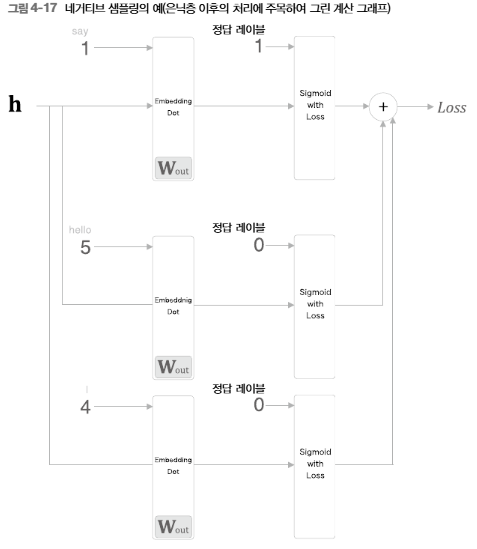   
- 그림에서 주의할 부분은 긍정적 예와 부정적 예를 다루는 방식
- 긍정적 예('say')에 대해서는 지금까지처럼 Sigmoid with Loss 계층에 정답 레이블로 '1'을 입력함
- 한편, 부정적 예('hello'와 'I')에 대해서는 Sigmoid with Loss 계층에 정답 레이블로 '0'을 입력함
- 그런 다음 각 데이터의 손실을 노두 더해 최종 손실을 출력함

### 네거티브 샘플링의 샘플링 기법

네거티브 샘플링에서 부정적 예를 샘플링할 때 단순히 무작위로 샘플링하는 것보다 좋은 방법이 있음   
바로 말뭉치의 통계 데이터를 기초로 샘플링하는 것   
구체적으로는, 말뭉치에서 자주 등장하는 단어를 많이 추출하고 드물게 등장하는 단어를 적게 추출하는 것   
말뭉치에서의 단어 빈도를 기준으로 샘플링하려면, 먼저 말뭉치에서 각 단어의 출현 횟수를 구해 '확률분포'로 나타냄   
그런 다음 그 확률분포대로 단어를 샘플링하면 됨   
ㅇ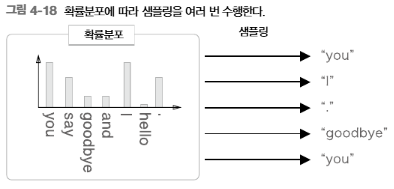   
- 말뭉치에서의 단어별 출현 횟수를 바탕으로 확률분포를 구한 다음, 그 확률분포에 따라서 샘플링을 수행하기만 하면 되
- 확률분포대로 샘플링하므로 말뭉치에서 자주 등장하는 단어는 선택될 가능성이 높음
- 같은 이유로, '희소한 단어'는 선택되기가 어려움   

> 네거티브 샘플링에서는 부정적 예를 가능한 한 많이 다루는 것이 좋지만, 계산량 문제 때문에 적은 수(5개나 10개 등)로 한정해야 함   
> 그런데 만약 '희소한 단어'만 선택되었다면 당연히 결과도 나빠질 것   
> 실전 문제에서도 희소한 단어는 거의 출현하지 않기 때문   
> 즉, 드문 단어를 잘 처리하는 일은 중요도가 낮음   
> 그보다는 흔한 단어를 잘 처리하는 편이 좋은 결과로 이어질 것   

그러면 확률분포네 따라 샘플링하는 예를 파이썬으로 구현하기   
이 용도에는 넘파이의 np.random.choice() 메서드를 사용할 수 있음   
이 메서드의 사용법을 보여주는 예시를 몇 가지 보면

In [8]:
import numpy as np

# 0에서 9까지의 숫자 중 하나를 무작위로 샘플링
print(np.random.choice(10))
print(np.random.choice(10))

# words에서 하나만 무작위로 샘플링
words = ['you', 'say', 'goodbye', 'I', 'hello', '.']
print(np.random.choice(words))

# 5개만 무작위로 샘플링(중복 있음)
print(np.random.choice(words, size=5))

# 5개만 무작위로 샘플링(중복 없음)
print(np.random.choice(words, size=5, replace=False))

# 확률분포에 따라 샘플링
p = [0.5, 0.1, 0.05, 0.2, 0.05, 0.1]
print(np.random.choice(words, p=p))

6
3
say
['goodbye' 'I' '.' 'hello' '.']
['say' 'you' 'I' '.' 'hello']
you


- 이 코드에서 보듯 np.random.choice()는 무작위 샘플링 용도로 이용할 수 있음
- 이때 인수로 size를 지정하면 샘플링을 size만큼 수행함
- 또한 인수에 replace=False를 지정하면 샘플링 시 중복을 없애줌
- 그리고 인수 p에 확률분포를 담은 리스트를 지정하면 그 확률분포대로 샘플링   

이제 이 함수를 사용해 부정적 예를 샘플링하기만 하면 됨   

그런데 word2vec의 네거티브 샘플링에서는 앞의 확률분포에서 한 가지를 수정하라고 권고하고 있음   
바로 아래 식처럼 기본 확률분포에 0.75를 제곱하는 것   
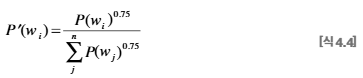   
- 여기서 P(wi)는 i번째 단어의 확률을 뜻함
- 이 식은 단순히 원래 확률분포의 각 요소를 '0.75 제곱'할 뿐
- 다만, 수정 후에도 확률의 총합은 1이 되어야 하므로, 분모로는 '수정 후 확률분포의 총합'이 필요   

위 식처럼 수정하는 이유는 출현 확률이 낮은 단어를 '버리지 않기' 위해서   
더 정확하게 말하면, '0.75 제곱'을 함으로써, 원래 확률이 낮은 단어의 확률을 살짝 높일 수 있음   
예시를 보면

In [9]:
p = [0.7, 0.29, 0.01]
new_p = np.power(p, 0.75)
new_p /= np.sum(new_p)
print(new_p)

[0.64196878 0.33150408 0.02652714]


- 이 예에서 보듯 수정 전 확률이 0.01(1%)이던 원소가, 수정 후에는 0.0265... (약 2.65%)로 높아졌음
- 이처럼 낮은 확률의 단어가 (조금 더) 쉽게 샘플링되도록 하기 위한 구제 조치로써 '0.75 제곱'을 수행함
- 참고로 0.75라는 수치에는 이론적인 의미는 없으니 다른 값으로 설정해도 됨   

지금까지 살펴본 것처럼 네거티브 샘플링은 말뭉치에서 단어의 확률분포를 만들고, 다시 0.75를 제곱한 다음, np.random.choice()를 사용해 부정적 예를 샘플링함   
이 책에서는 이 처리를 담당하는 클래스를 UnigramSampler라는 이름으로 만듦

> 유니그램(Unigram)이란 '하나의 (연속된) 단어'를 뜻함   
> 같은 요령으로 바이그램(Bigram)은 '2개의 연속된 단어'를, 트라이그램(Trigram)은 '3개의 연속된 단어'를 뜻함   
> 그래서 UnigramSampler 클래스의 이름에는 한 단어를 대상으로 확률분포를 만든다는 의미가 녹아 있음   
> 만약 이를 '바이그램' 버전으로 만든다면 ('you', 'say'),  ('you', 'goodbye') ... 같이 두 단어로 구성된 대상에 대한 확률분포를 만들게 됨   

In [10]:
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
import collections

class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy()
                target_idx = target[i]
                p[target_idx] = 0
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            # GPU(cupy）로 계산할 때는 속도를 우선
            # 부정적 예에 타깃이 포함될 수 있음
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)

        return negative_sample

- UnigramSampler 클래스는 초기화 시 3개의 인수를 받음
    - 단어 ID 목록인 corpus, 확률분포에 '제곱'할 값인 power(기본값은 0.75), '부정적 예 샘플링'을 수행하는 횟수인 sample_size
- 또한 UnigramSampler 클래스는 get_negative_sample(target) 메서드를 제공
    - 이 메서드는 target 인수로 지정한 단어를 긍정적 예로 해석하고, 그 외의 단어 ID를 샘플링함(즉, 부정적 예를 골라줌)   

그러면 UnigramSampler 클래스를 사용하는 모습을 보면

In [11]:
corpus = np.array([0, 1, 2, 3, 4, 1, 2, 3])
power = 0.75
sample_size = 2

sampler = UnigramSampler(corpus, power, sample_size)
target = np.array([1, 3, 0])
negative_sample = sampler.get_negative_sample(target)

print(negative_sample)

[[2 4]
 [1 4]
 [2 4]]


- 여기에서는 긍정적 예로 [1, 3, 0]이라는 3개의 데이터를 미니배치로 다뤘음
- 이 각각의 데이터에 대해서 부정적 예를 2개씩 샘플링함
- 이 예에서는 첫 번째 데이터에 대한 부정적 예는 [0 3], 두 번째는 [1 2], 3번째는 [2 3]이 뽑혔음을 알 수 있음(실행할 때마다 결과가 달라질 수 있음)   

이제 부정적 예를 샘플링할 수 있게 되었음

### 네거티브 샘플링 구현

마지막으로 네거티브 샘플링르 구현해보기   
NegativeSamplingLoss라는 클래스로 구현   

우선 초기화 메서드

In [12]:
import sys
sys.path.append('..')
from common.layers import Embedding, SigmoidWithLoss

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

- 초기화 메서드의 인수로는 출력 측 가중치를 나타내는 W, 말뭉치(단어 ID의 리스트)를 뜻하는 corpus, 확률분포에 제곱할 값인 power, 부정적 예의 샘플링 횟수인 sample
- 여기에서는 앞 절에서 설명한 UnigramSampler 클래스를 생성하여 인스턴스 변수인 sampler로 저장함
- 또한 부정적 예의 샘플링 횟수는 인스턴스 변수인 sample_size에 저장함
- 인스턴스 변수인 loss_layers와 embed_dot_layers에는 원하는 계층을 리스트로 보관
- 이때 이 두 리스트에는 sample_size + 1개의 계층을 생성하는데,
    - 부정적 예를 다루는 계층이 sample_size개만큼이고, 여기에 더해 긍정적 예를 다루는 계층이 하나 더 필요하기 때
    - 정확히는 0번째 계층, 즉 loss_layers[0]과 embed_dot_layers[0]이 긍정적 예를 다루는 계층
- 그런 다음 이 계층에서 사용하는 매개변수와 기울기를 각각 배열로 저장함   

이어서 순전파의 구현

In [13]:
def forward(self, h, target):
    batch_size = target.shape[0]
    negative_sample = self.sampler.get_negative_sample(target)

    # 긍정적 예 순전파
    score = self.embed_dot_layers[0].forward(h, target)
    correct_label = np.ones(batch_size, dtype=np.int32)
    loss = self.loss_layers[0].forward(score, correct_label)

    # 부정적 예 순전파
    negative_label = np.zeros(batch_size, dtype=np.int32)
    for i in range(self.sample_size):
        negative_target = negative_sample[:, i]
        score = self.embed_dot_layers[1 + i].forward(h, negative_target)
        loss += self.loss_layers[1 + i].forward(score, negative_label)

- forward(h, target) 메서드가 받는 인수는 은닉층 뉴런 h와 긍정적 예의 타깃을 뜻하는 target
- 이 메서드에서는 우선 self.sampler를 이용해 부정적 예를 샘플링하여 negative_sample에 저장함
- 그런 다음 긍정적 예와 부정적 예 각각의 데이터에 대해서 순전파를 수행해 그 손실들을 더함
- 구체적으로는 Embedding Dot 계층의 forward 점수를 구하고, 이어서 이 점수와 레이블을 Sigmoid with Loss 계층으로 흘려 손실을 구함
- 여기에서 긍정적 예의 정답 레이블(correct_label)은 '1'이고, 부정적 예의 정답 레이블(negative_label)은 '0'임에 주의   

마지막으로 역전파 구현

In [14]:
def backward(self, dout=1):
    dh = 0
    for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
        dscore = l0.backward(dout)
        dh += l1.backward(dscore)

    return dh

- 역전파의 구현은 간단
- 순전파 때의 역순으로 각 계층의 backward()를 호출하기만 하면 됨
- 은닉층의 뉴런은 순전파 시에 여러 개로 복사되었음
- 이는 이전에 설명한 Repeat 노드에 해당
- 따라서 역전파 때는 여러 개의 기울기 값을 더해줌

In [15]:
class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 긍정적 예 순전파
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 부정적 예 순전파
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh

## 개선판 word2vec 학습

지금까지 기존 word2vec을 개선해봤음   
가장 먼저 Embedding 계층을 살펴보고, 이어서 네거티브 샘플링 기법도 살펴봄   
그리고 이 두 가지를 실제로 구현했음   
그럼 이러한 개선을 신경망 구현에 적용   
그런 다음 PTB 데이터셋을 사용해 학습하고 더 실용적인 단어의 분산 표현을 얻어볼 예정

### CBOW 모델 구현

이번에도 CBOW 모델을 구현해볼 텐데, 앞 장의 단순한 SimpleCBOW 클래스를 개선할 것   
개선점은 Embedding 계층과 Negative Sampling Loss 계층을 적용하는 것   
나아가 맥락의 윈도우 크기를 임의로 조절할 수 있도록 확장   

개선된 CBOW 클래스의 모습은 다음과 같음   
우선 초기화 메서드부터 보면

In [16]:
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Embedding

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # 계층 생성
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)  # Embedding 계층 사용
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 모든 가중치와 기울기를 배열에 모음
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장
        self.word_vecs = W_in

- 이 초기화 메서드는 4개의 인수를 받음
- vocab_size는 어휘 수, hidden_size는 은닉층의 뉴런 수, corpus는 단어 ID 목록
- 그리고 맥락의 크기(주변 단어 중 몇 개나 맥락으로 포함시킬지)를 window_size로 지정
- 예컨대 window_size가 2이면 타깃 단어의 좌우 2개씩, 총 4개 단어가 맥락이 됨   

> SimpleCBOW 클래스 (개선 전의 구현)에서는 입력 측의 가중치와 출력 측의 가중치의 형상이 달라서 출력 측의 가중치에서는 단어 벡터가 열 방향으로 배치되었음   
> 한편 CBOW 클래스의 출력 측 가중치는 입력 측 가중치와 같은 형상으로, 단어 벡터가 행 방향에 배치됨   
> 그 이유는 NegativeSamplingLoss 클래스에서 Embedding 계층을 사용하기 때문   

- 가중치 초기화가 끝나면, 이어서 계층을 생성함
- 여기에서는 Embedding 계층을 2 * window_size개 작성하여 인스턴스 변수인 in_layers에 배열로 보관
- 그런 다음 Negative Sampling Loss 계층을 생성
- 계층을 다 생성했으면, 이 신경망에서 사용하는 모든 매개변수와 기울기를 인스턴스 변수인 params와 grads에 모음
- 또한 나중에 단어의 분산 표현에 접근할 수 있도록 인스턴스 변수인 word_vecs에 가중치 W_in을 할당함   

속해서 순전파와 역전파를 처리하는 forward()와 backward() 메서드

In [17]:
def forward(self, contexts, target):
    h = 0
    for i, layer in enumerate(self.in_layers):
        h += layer.forward(contexts[:, i])
    h *= 1 / len(self.in_layers)
    loss = self.ns_loss.forward(h, target)
    return loss

def backward(self, dout=1):
    dout = self.ns_loss.backward(dout)
    dout *= 1 / len(self.in_layers)
    for layer in self.in_layers:
        layer.backward(dout)
    return None

- 이 구현은 각 계층의 순전파 (혹은 역전파)를 적절한 순서로 호출할 뿐
- 앞 장의 SimpleCBOW 클래스를 자연스럽게 확장한 것
- 단, forward(contexts, target) 메서드가 인수로 받는 맥락과 타깃이 단어 ID라는 점이 다름(앞 장에서는 단어 ID를 원핫 벡터로 변환해서 사용했음)   

구체적인 예를 보면   
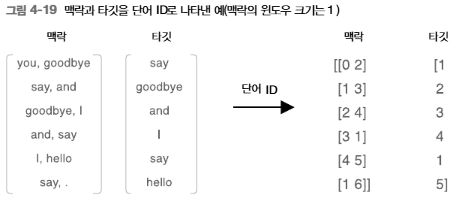   
- 그림의 오른쪽에 보이는 단어 ID의 배열이 contexts와 target의 예
- 보다시피 contexts는 2차원 배열이고 target은 1차원 배열입니다
- 이러한 데이터가 forward(contexts, target)에 입력되는 것   

이상이 CBOW 클래스의 설명

In [18]:
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Embedding

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # 계층 생성
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)  # Embedding 계층 사용
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 모든 가중치와 기울기를 배열에 모음
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None

### CBOW 모델 학습 코드

마지막으로 CBOW 모델의 학습을 구현   
여기에서는 단순히 신경망 학습을 수행할 뿐

| 에폭 1 |  반복 1 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 21 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 41 / 9295 | 시간 1[s] | 손실 4.15
| 에폭 1 |  반복 61 / 9295 | 시간 2[s] | 손실 4.12
| 에폭 1 |  반복 81 / 9295 | 시간 3[s] | 손실 4.05
| 에폭 1 |  반복 101 / 9295 | 시간 4[s] | 손실 3.93
| 에폭 1 |  반복 121 / 9295 | 시간 5[s] | 손실 3.78
| 에폭 1 |  반복 141 / 9295 | 시간 6[s] | 손실 3.63
| 에폭 1 |  반복 161 / 9295 | 시간 7[s] | 손실 3.49
| 에폭 1 |  반복 181 / 9295 | 시간 7[s] | 손실 3.37
| 에폭 1 |  반복 201 / 9295 | 시간 8[s] | 손실 3.24
| 에폭 1 |  반복 221 / 9295 | 시간 9[s] | 손실 3.17
| 에폭 1 |  반복 241 / 9295 | 시간 10[s] | 손실 3.08
| 에폭 1 |  반복 261 / 9295 | 시간 11[s] | 손실 3.02
| 에폭 1 |  반복 281 / 9295 | 시간 12[s] | 손실 2.98
| 에폭 1 |  반복 301 / 9295 | 시간 13[s] | 손실 2.92
| 에폭 1 |  반복 321 / 9295 | 시간 14[s] | 손실 2.88
| 에폭 1 |  반복 341 / 9295 | 시간 14[s] | 손실 2.84
| 에폭 1 |  반복 361 / 9295 | 시간 15[s] | 손실 2.80
| 에폭 1 |  반복 381 / 9295 | 시간 16[s] | 손실 2.78
| 에폭 1 |  반복 401 / 9295 | 시간 17[s] | 손실 2.76
| 에폭 1 |  반복 421 / 9295 | 시간 18[s] | 손실 2.74
| 에폭 1 |  반복 441 / 9295 | 시간

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


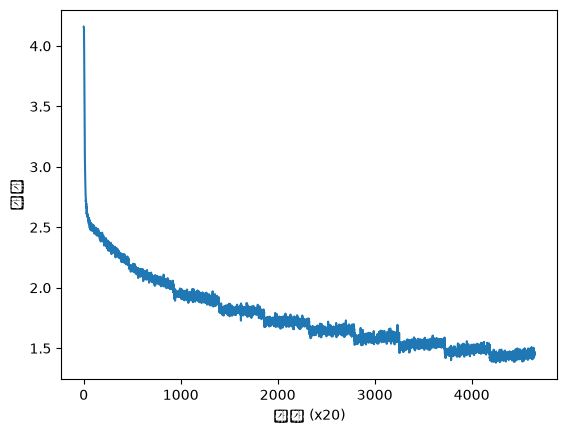

In [2]:
# coding: utf-8
import sys
sys.path.append('..')
import numpy as np
from common import config
# GPU에서 실행하려면 아래 주석을 해제하세요(CuPy 필요).
# ===============================================
# config.GPU = True
# ===============================================
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from cbow import CBOW
from skip_gram import SkipGram
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb


# 하이퍼파라미터 설정
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

# 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# 모델 등 생성
model = CBOW(vocab_size, hidden_size, window_size, corpus)
# model = SkipGram(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 학습 시작
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 나중에 사용할 수 있도록 필요한 데이터 저장
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl'  # or 'skipgram_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

- 이번 CBOW 모델은 윈도우 크기를 5로, 은닉층의 뉴런 수를 100개로 설정
- 사용하는 말뭉치에 따라 다르지만, 윈도우 크기는 2~10개, 은닉층의 뉴런 수(단어의 분산 표현의 차원 수)는 50~500개 정도면 좋은 결과를 얻을 것

이번에 다루는 PTB는 지금까지의 말뭉치보다 월등히 커서 학습 시간이 상당히 오래 걸림   
그래서 GPU를 사용할 수 있는 모드를 준비   

학습이 끝나면 가중치를 꺼내 (여기에서는 입력 측 가중치만), 나중에 이용할 수 있도록 파일에 보관(단어와 단어 ID 변환을 위해 사전도 함께 보관)   
파일로 저장할 때는 파이썬의 '피클(pickle)' 기능을 이용   
피클은 파이썬 코드의 객체를 파일로 저장 (또는 파일에서 읽기)하는 데 이용할 수 있음   

> 참고로 학습된 가중치 데이터는 각자가 학습한 환경에 따라 다름   
> 학습 과정에서 무작위 값이 쓰이기 때문인데, 예컨대 가중치 초기화에 이용하는 초깃값, 미니배치 선택, 네거티브 샘플링에서의 샘플링이 무작위로 이뤄짐   
> 이러한 무작위성 때문에 최종적으로 얻는 가중치가 각자의 환경에 따라 달라지지만, 거시적으로 보면 비슷한 결과(경향)를 얻을 수 있음

### CBOW 모델 평가

그러면 앞 절에서 학습한 단어의 분산 표현을 평가하기   
2장에서 구현한 most_similar() 메서드를 이용하여, 단어 몇 개에 대해 거리가 가장 가까운 단어들을 뽑아보기

In [8]:
import sys
sys.path.append('..')
from common.util import most_similar, analogy
import pickle


pkl_file = 'cbow_params.pkl'
# pkl_file = 'skipgram_params.pkl'

with open(pkl_file, 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']

# 가장 비슷한(most similar) 단어 뽑기
querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


[query] you
 we: 0.71044921875
 i: 0.69482421875
 they: 0.6025390625
 your: 0.5859375
 anything: 0.5830078125

[query] year
 month: 0.8525390625
 summer: 0.78564453125
 week: 0.7724609375
 spring: 0.7626953125
 decade: 0.67431640625

[query] car
 truck: 0.6513671875
 luxury: 0.607421875
 window: 0.56591796875
 cars: 0.5634765625
 exporter: 0.56005859375

[query] toyota
 engines: 0.6396484375
 honda: 0.63330078125
 mazda: 0.62451171875
 seita: 0.60009765625
 fuel: 0.59423828125


- 이 코드를 실행하면 다음 결과를 얻을 수 있습니다 (이 결과는 각자의 학습 환경에 따라 다를 수 있음)   
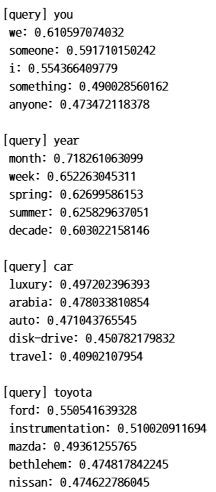   

- 결과를 보면 우선은 'you'를 물으니 비슷한 단어로 인칭대명사 'i(=I)'와 'we' 등이 나왔음
- 'year'에 대해서는 'month'와 'week' 같은 기간을 뜻하는 같은 성격의 단어들이 나왔음
- 그리고 'toyota'에 대해서는 'ford', 'mazda', 'nissan' 같은 자동차 메이커가 나왔음   

이 결과를 보면 CBOW 모델로 획득된 단어의 분산 표현은 제법 괜찮은 특성을 지닌다고 말할 수 있음   

word2vec으로 얻은 단어의 분산 표현은 비슷한 단어를 가까이 모을 뿐 아니라, 더 복잡한 패턴을 파악하는 것으로 알려져 있음   
대표적인 예가 'king - man + woman = queen'으로 유명한 유추 문제(비유 문제)   
더 정확하게 말하면, word2vec의 단어의 분산 표현을 사용하면 유추 문제를 벡터의 덧셈과 뺄셈으로 풀 수 있다는 뜻   

실제로 유추 문제를 풀려면 아래 그림처럼 단어 벡터 공간에서 'man → woman' 벡터와 'king → ?' 벡터가 가능한 한 가까워지는 단어를 찾음   
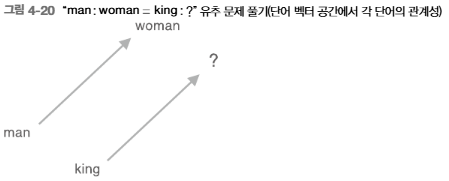   

- 단어 'man'의 분산 표현(단어 벡터)을 'vec('man')'이라고 표현   
- 그러면 위 그림에서 얻고 싶은 관계를 수식으로 나타내면 "vec('woman') - vec('man') = vec(?) - vec('king')"이 됨
- 즉, 풀어야 하는 문제는 "vec('king') + vec('woman') - vec('man') = vec(?)"라는 벡터에 가장 가까운 단어 벡터를 구하는 일이 됨
- 이 로직을 구현한 함수는 common/utill.py 파일의 analogy()
- 이 함수를 사용하면 지금과 같은 유추 문제를 analogy('man', 'king', 'woman', word_to_id, id_to_word, word_vecs, top=5)라는 한 줄로 처리할 수 있음   

이 함수를 실행하면 결과가 다음과 같은 형태로 출력됨   
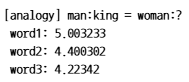   
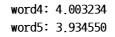   
- 이와 같이 첫 번째 줄에 문제 문장이 출력되고, 다음 줄부터는 점수가 높은 순으로 5개의 단어가 출력됨
- 각 단어 옆에는 점수가 표시됨   

그러면 실제로 유추 문제를 몇 가지 풀어보면

In [9]:
# 유추(analogy) 작업
print('-'*50)
analogy('king', 'man', 'queen',  word_to_id, id_to_word, word_vecs)
analogy('take', 'took', 'go',  word_to_id, id_to_word, word_vecs)
analogy('car', 'cars', 'child',  word_to_id, id_to_word, word_vecs)
analogy('good', 'better', 'bad',  word_to_id, id_to_word, word_vecs)

--------------------------------------------------

[analogy] king:man = queen:?
 woman: 5.01953125
 a.m: 4.640625
 actor: 4.53515625
 father: 4.48828125
 thing: 4.4296875

[analogy] take:took = go:?
 eurodollars: 4.60546875
 were: 4.23828125
 came: 4.203125
 went: 4.1328125
 're: 4.09375

[analogy] car:cars = child:?
 a.m: 5.5703125
 rape: 5.515625
 children: 5.4296875
 adults: 4.95703125
 incest: 4.8984375

[analogy] good:better = bad:?
 rather: 5.8359375
 more: 5.76171875
 less: 5.4765625
 greater: 4.421875
 worse: 3.90234375


- 결과는 기대한 대로 나옴
- 첫 번째 문제 "king : man = queen :  ?"의 대답은 'woman'
- 두 번째 문제 "take : took = go : ?"도 기대한 대로 'went'라
- 이는 현재형과 과거형 패턴을 파악하고 있다는 증거이므로, 시제 정보가 단어의 분산 표현에 인코딩되고 있다고 해석할 수 있음
- 그리고 세 번째 문제에서는 단수형과 복수형을 올바르게 파악하고 있음을 알 수 있음
- 안타깝게도 네 번째의 "good : better = bad : ?" 질문에는'“worse'라고 대답하지 않았음
- 하지만 'more'와 'less' 등의 비교급 단어를 제시한 걸 보면, 비교급이라는 성질도 단어의 분산 표현에 인코딩되어 있음을 알 수 있음   

이처럼 word2vec으로 얻은 단어의 분산 표현을 사용하면, 벡터의 덧셈과 뺄셈으로 유추 문제를 풀 수 있음   
단어의 단순한 의미뿐 아니라 문법적인 패턴도 파악할 수 있는 것   
그밖에도 'good'과 'best' 사이에는 'better'가 존재한다고 하는 관계성 등, word2vec에서 얻은 단어의 분산 표현에는 흥미로운 결과가 얼마든지 발견되고 있음   

> 앞서 본 유추 문제의 결과는 아주 뛰어나 보였지만, 안타깝게도 잘 풀리는 문제만 선별했기 때문   
> 사실 원하는 결과를 얻지 못하는 문제도 많을 것   
> PTB 데이터셋이 작다는 것이 주된 원인   
> 만약 큰 말뭉치로 학습하면, 더 정확하고 더 견고한 단어의 분산 표현을 얻을 수 있으므로 유추 문제의 정답률(정확도(accuracy))도 크게 향상될 것

## word2vec 남은 주제

### word2vec을 사용한 애플리케이션의 예

word2vec으로 얻은 단어의 분산 표현은 비슷한 단어를 찾는 용도로 이용할 수 있음   
그러나 단어 분산 표현의 장점은 여기서 끝이 아님   
자연어 처리 분야에서 단어의 분산 표현이 중요한 이유는 **전이 학습(transfer learning)** 에 있음   
전이 학습은 한 분야에서 배운 지식을 다른 분야에도 적용하는 기법   

자연어 문제를 풀 때 word2vec의 단어 분산 표현을 처음부터 학습하는 일은 거의 없음   
그 대신 먼저 큰 말뭉치(위키백과나 구글 뉴스의 텍스트 데이터 등)로 학습을 끝난 후, 그 분산 표현을 각자의 작업에 이용하는 것   
예컨대 텍스트 분류, 문서 클러스터링, 품사 태그 달기, 감정 분석 등 자연어 처리 작업이라면 가장 먼저 단어를 벡터로 변환하는 작업을 해야 하는데,   
이때 학습을 미리 끝낸 단어의 분산 표현을 이용할 수 있음   
그리고 이 학습된 분산 표현이 방금 언급한 자연어 처리 작업 대부분에 훌륭한 결과를 가져다줌   

단어의 분산 표현은 단어를 고정 길이 벡터로 변환해준다는 장점도 있음   
게다가 문장(단어의 흐름)도 단어의 분산 표현을 사용하여 고정 길이 벡터로 변환할 수 있음   
문장을 고정 길이 벡터로 변환하는 방법은 활발하게 연구되고 있는데, 가장 간단한 방법은 문장의 각 단어를 분산 표현으로 변환하고 그 합을 구하는 것   
이를 bag-of-words라 하여, 단어의 순서를 고려하지 않는 모델   
또한 5장에서 설명하는 순환 신경망(RNN)을 사용하면 한층 세련된 방법으로 (word2vec의 단어의 분산 표현을 이용하면서) 문장을 고정 길이 벡터로 변환할 수 있음   

단어나 문장을 고정 길이 벡터로 변환할 수 있다는 점은 매우 중요   
자연어를 벡터로 변환할 수 있다면 일반적인 머신러닝 기법(신경망이나 SVM 등)을 적용할 수 있기 때문   
이를 그림으로 나타내면 아래 그림처럼 됨   
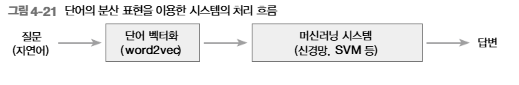   
- 그림에서 보듯 자연어로 쓰여진 질문을 고정 길이 벡터로 변환할 수 있다면, 그 벡터를 다른 머신러닝 시스템의 입력으로 사용할 수 있음
- 자연어를 벡터로 변환함으로써 일반적인 머신러닝 시스템의 틀에서 원하는 답을 출력하는 것(그리고 학습하는 것)이 가능해짐   

> 그림의 파이프라인에서는 단어의 분산 표현 학습과 머신러닝 시스템의 학습은 서로 다른 데이터셋을 사용해 개별적으로 수행하는 것이 일반적   
> 예컨대 단어의 분산 표현은 위키백과와 같은 범용 말뭉치를 사용해 미리 학습해둠   
> 그리고 현재 직면한 문제에 관련하여 수집한 데이터를 가지고 머신러닝 시스템(SVM 등)을 학습시킴   
> 다만, 직면한 문제의 학습 데이터가 아주 많다면 단어의 분산 표현과 머신러닝 시스템 학습 모두를 처음부터 수행하는 방안도 고려해볼 수 있음   

그럼 구체적인 예를 보면서 단어의 분산 표현 사용법을 살펴보면   
- 사용자가 1억 명 이상인 스마트폰 앱을 개발·운영하고 있다고 가정
- 회사가 감당하기 어려울 정도의 메일이 사용자로부터 매일 쏟아져 들어옴
- 그중에는 호의적인 의견도 있는 반면, 불만의 목소리도 존재할 것   

그래서 받은 메일을 자동으로 분류하는 시스템을 만들 고민을 함   
예컨대 아래 그림처럼 메일의 내용을 보고 사용자의 감정을 3단계로 분류할 수는 없을지 고민함   
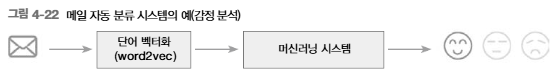   
사용자의 감정을 정확하게 분류할 수 있다면, 불만을 가진 사용자의 메일부터 순서대로 살펴볼 수 있음   
그러면 앱의 치명적인 문제를 조기에 발견하고 손을 쓸 수 있을지도 모름   
자연스럽게 사용자 만족도도 높아질 것   

- 메일 자동 분류 시스템을 만들려면, 우선 데이터(메일)를 수집해야 함   
- 지금 예에서는 사용자가 보낸 메일을 모으고, 모은 메일들에 수동으로 레이블을 붙임   
- 예컨대 3단계의 감정을 나타내는 레이블(긍정적(positive), 중립적(neutral), 부정적(negative))을 붙임   
- 레이블링 작업이 끝나면 학습된 word2vec을 이용해 메일을 벡터로 변환
- 그런 다음 감정 분석을 수행하는 어떤 분류 시스템(SVM이나 신경망 등)에 벡터화된 메일과 감정 레이블을 입력하여 학습을 수행   

이 예처럼 자연어를 다루는 문제는 단어의 분산 표현이라는 방법으로 벡터화할 수 있음   
그 덕분에 일반적인 머신러닝 기법으로 해결할 수 있게 됨   
게다가 word2vec 전이 학습의 혜택을 누릴 수 있음   
즉, 다양한 자연어 처리 문제에서 word2vec으로 구축한 단어의 분산 표현을 이용함으로써 정확도를 높일 수 있음

### 단어 벡터 평가 방법

word2vec을 통해 단어의 분산 표현을 얻을 수 있었음   
그러면 그 분산 표현이 좋은지는 어떻게 평가하는지 간략히 설명   

단어의 분산 표현은 앞 절에서 본 감정 분석 예처럼, 현실적으로는 특정한 애플리케이션에서 사용되는 것이 대부분   
그렇다면 우리가 궁극적으로 원하는 것은 정확도 높은 시스템   
여기서 생각해야 하는 것이 그 시스템(예컨대 감정 분석 시스템)은 여러 시스템으로 구성된다는 것   
여러 시스템이란, 앞의 예로 말하면 단어의 분산 표현을 만드는 시스템(word2vec)과 특정 문제에 대해 분류를 수행하는 시스템(예컨대 감정을 분류하는 SVM 등)   

단어의 분산 표현을 만드는 시스템과 분류하는 시스템의 학습은 따로 수행할 수도 있음   
그 경우, 예컨대 단어의 분산 표현의 차원 수가 최종 정확도에 어떤 영향을 주는지를 조사하려면,   
우선 단어의 분산 표현을 학습하고, 그 분산 표현을 사용하여 또 하나의 머신러닝 시스템을 학습시켜야 함   
즉, 두 단계의 학습을 수행한 다음 평가해야 할 것   
또한, 이 경우 두 시스템 각각에서 최적의 하이퍼파라미터를 찾기 위한 튜닝도 필요하므로, 그만큼 시간이 오래 걸림   

그래서 단어의 분산 표현의 우수성을 실제 애플리케이션과는 분리해 평가하는 것이 일반적   
이때 자주 사용되는 평가 척도가 단어의 '유사성'이나 '유추 문제'를 활용한 평가   

단어의 유사성 평가에서는 사람이 작성한 단어 유사도를 검증 세트를 사용해 평가하는 것이 일반적   
- 예를 들어 유사도를 0에서 10 사이로 점수화한다면, 'cat'과 'animal'의 유사도는 8점, 'cat'과 'car'의 유사도는 2점과 같이, 사람이 단어 사이의 유사한 정도를 규정함
- 그리고 사람이 부여한 점수와 word2vec에 의한 코사인 유사도 점수를 비교해 그 상관성을 보는 것   

유추 문제를 활용한 평가는 "king : queen = man : ?"와 같은 유추 문제를 출제하고, 그 정답률로 단어의 분산 표현의 우수성을 측정   
예컨대 아래 그림은 유추 문제에 의한 평가 결과가 실려 있는 논문의 일부를 발췌한 것   
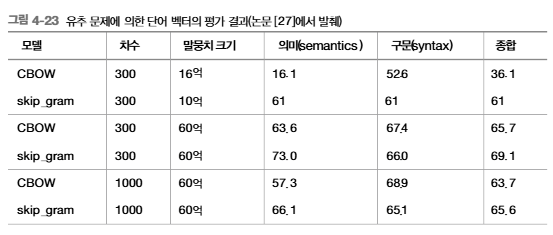   
- 그림은 word2vec 모델, 단어의 분산 표현의 차원 수, 말뭉치의 크기를 매개변수로 사용해 비교 실험을 수행한 결과
- 각각의 결과는 오른쪽의 세 열
- 표의 '의미(semantics)' 열은 단어의 의미를 유추하는 유추 문제의 정답률을 보여줌
- 예컨대 "king : queen = actor : actress"와 같이 단어의 의미를 묻는 문제
- 한편 '구문(syntax)' 열은 단어의 형태 정보를 묻는 문제로, 예컨대 "bad : worst = good : best" 같은 문제를 말함   

> 그림의 결과로부터 다음 사항을 알 수 있음   
>> 모델에 따라 정확도가 다름(말뭉치에 따라 적합한 모델 선택)   
>> 일반적으로 말뭉치가 클수록 결과가 좋음(항상 데이터가 많은 게 좋음)   
>> 단어 벡터 차원 수는 적당한 크기가 좋음(너무 커도 정확도가 나빠짐)   

유추 문제를 이용하면 '단어의 의미나 문법적인 문제를 제대로 이해하고 있는지'를 (어느 정도) 측정할 수 있음   
그러므로 유추 문제를 정확하게 풀 수 있는 단어의 분산 표현이라면 자연어를 다루는 애플리케이션에서도 좋은 결과를 기대할 수 있을 것   
다만, 단어의 분산 표현의 우수함이 애플리케이션에 얼마나 기여하는지(혹은 기여하지 않는지)는 애플리케이션 종류나 말뭉치의 내용 등, 다루는 문제 상황에 따라 다름   
즉, 유추 문제에 의한 평가가 높다고 해서 애플리케이션에서도 반드시 좋은 결과가 나오리라는 보장은 없음 - 이 점은 주의

## 정리

이번 장에서는 word2vec 고속화를 주제로 앞 장의 CBOW 모델을 개선했음   
구체적으로는 Embedding 계층을 구현하고 네거티브 샘플링이라는 새로운 기법을 도입   
이렇게 한 배경에는 말뭉치의 어휘 수 증가에 비례해 계산량이 증가하는 문제가 있었음   

이번 장에서의 핵심은 '모두' 대신 '일부'를 처리하는 것   
인간 역시 모든 것을 알 수 없듯이 컴퓨터도 (현재의 성능으로는) 모든 데이터를 처리하는 것은 비현실적   
그보다는 꼭 필요한 일부에 집중하는 편이 얻는 게 많음   
이번 장에서는 이 생각에 기초한 기법인 네거티브 샘플링을 자세하게 살펴봤음   
네거티브 샘플링은 '모든' 단어가 아닌 '일부' 단어만을 대상으로 하는 것으로, 계산을 효율적으로 수행해줌   

앞 장과 이번 장으로 word2vec을 주제로 하는 일련의 이야기를 마무리   
word2vec은 자연어 처리 분야에 큰 영향을 주었음   
여기서 얻은 단어의 분산 표현은 다양한 자연어 처리 작업에 이용되고 있고, word2vec의 사상은 자연어뿐 아니라 다른 분야(음성, 이미지, 동영상 등)에도 응용되고 있음

### 이번 장에서 배운 내용

- Embedding 계층은 단어의 분산 표현을 담고 있으며, 순전파 시 지정한 단어 ID의 벡터를 추출함
- word2vec은 어휘 수의 증가에 비례하여 계산량도 증가하므로, 근사치로 계산하는 빠른 기법을 사용하면 좋음
- 네거티브 샘플링은 부정적 예를 몇 개 샘플링하는 기법으로, 이를 이용하면 다중 분류를 이진 분류처럼 취급할 수 있음
- word2vec으로 얻은 단어의 분산 표현에는 단어의 의미가 녹아들어 있으며, 비슷한 맥락에서 사용되는 단어는 단어 벡터 공간에서 가까이 위치
- word2vec의 단어의 분산 표현을 이용하면 유추 문제를 벡터의 덧셈과 뺄셈으로 풀 수 있게 됨
- word2vec은 전이 학습 측면에서 특히 중요하며, 그 단어의 분산 표현은 다양한 자연어 처리 작업에 이용할 수 있음